# Partie 3 - MultiModal Classification (California)

Notebook de reproduction de la Partie 3 (inspiree de `Arkanssas/partie3`) adapte au dataset California.

Pipeline:
1. Chargement et alignement multimodal (S2 + masque + S1 + statiques)
2. Audit des donnees
3. Split stratifie + normalisation
4. Ablation des configurations multimodales
5. Export des resultats

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(r"C:/Users/pc/Desktop/projet_rcr/california")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from partie3.multimodal_data import (
    load_aligned_multimodal,
    stratified_train_val_test_indices,
    standardize_modalities_fit_transform,
)
from partie3.dataset_audit import print_multimodal_audit
from partie3.train_ablation import run_ablation_suite

SEED = 42
np.random.seed(SEED)
print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"SEED={SEED}")

PROJECT_ROOT=C:\Users\pc\Desktop\projet_rcr\california
SEED=42


In [2]:
# 1) Chargement multimodal aligne
X_s2, M_s2, X_s1, X_static, y, meta = load_aligned_multimodal(
    PROJECT_ROOT,
    n_classes=6,
    id_col="id",
)
print("Shapes:")
print("X_s2:", X_s2.shape)
print("M_s2:", M_s2.shape)
print("X_s1:", X_s1.shape)
print("X_static:", X_static.shape)
print("y:", y.shape)
display(meta.head())

Shapes:
X_s2: (9996, 36, 10)
M_s2: (9996, 36)
X_s1: (9996, 12, 3)
X_static: (9996, 10)
y: (9996,)


,id
0,0
1,1
2,2
3,3
4,4


In [3]:
# 2) Audit des donnees
class_names = ("Grapes", "Rice", "Alfalfa", "Almonds", "Pistachios", "Others")
print_multimodal_audit(PROJECT_ROOT, X_s2, X_s1, X_static, y, class_names=class_names)

--- Audit multimodal California ---
Processed S2 rows (raw): 9996
After S1 ∩ static merge: 9996
Dropped rows (no match): 0

Shapes: S2 (9996, 36, 10) | S1 (9996, 12, 3) | static (9996, 10)
NaN S2: 0 | S1: 0 | static: 0

Class distribution:
  0 Grapes: 2053 (20.5%)
  1 Rice: 2037 (20.4%)
  2 Alfalfa: 973 (9.7%)
  3 Almonds: 783 (7.8%)
  4 Pistachios: 640 (6.4%)
  5 Others: 3510 (35.1%)


In [4]:
# 3) Split stratifie + normalisation
idx_train, idx_val, idx_test = stratified_train_val_test_indices(
    y,
    test_size=0.15,
    val_size=0.15,
    random_state=SEED,
)
(X_s2_n, X_s1_n, X_static_n), scalers = standardize_modalities_fit_transform(
    X_s2, X_s1, X_static, idx_train
)
print("Split sizes:", len(idx_train), len(idx_val), len(idx_test))

Split sizes: 6996 1500 1500


In [5]:
# 4) Entrainement ablation
ablation = run_ablation_suite(
    X_s2_n,
    M_s2,
    X_s1_n,
    X_static_n,
    y,
    idx_train,
    idx_val,
    idx_test,
    n_classes=6,
    epochs=40,
    batch_size=64,
    random_seed=SEED,
)
print("Ablation terminee. Configs:", list(ablation.keys()))


Epoch 1/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 26s 81ms/step - accuracy: 0.6935 - loss: 0.9382 - top2: 0.8266 - val_accuracy: 0.1853 - val_loss: 2.3546 - val_top2: 0.4953 - learning_rate: 0.0010
Epoch 2/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.8168 - loss: 0.5550 - top2: 0.9182 - val_accuracy: 0.6107 - val_loss: 1.0848 - val_top2: 0.8273 - learning_rate: 0.0010
Epoch 3/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - accuracy: 0.8513 - loss: 0.4538 - top2: 0.9365 - val_accuracy: 0.8193 - val_loss: 0.5606 - val_top2: 0.9273 - learning_rate: 0.0010
Epoch 4/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.8705 - loss: 0.3891 - top2: 0.9477 - val_accuracy: 0.8627 - val_loss: 0.4291 - val_top2: 0.9407 - learning_rate: 0.0010
Epoch 5/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.8849 - loss: 0.3537 - top2: 0.9525 - val_accuracy: 0.8433 - val_loss: 0.4485 - val_top2: 0.9353 - learning_rate: 0.0010
Epoch 6/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy

In [6]:
# 5) Resume + export CSV
rows = []
for name, info in ablation.items():
    hist = info["history"].history
    best_idx = int(np.argmin(hist["val_loss"]))
    rows.append({
        "config": name,
        "test_loss": float(info["test_loss"]),
        "test_accuracy": float(info["test_accuracy"]),
        "test_top2": float(info["test_top2"]),
        "best_epoch": best_idx + 1,
        "best_val_loss": float(hist["val_loss"][best_idx]),
        "best_val_accuracy": float(hist["val_accuracy"][best_idx]),
    })

res_df = pd.DataFrame(rows).sort_values("test_accuracy", ascending=False)
display(res_df)

out_dir = PROJECT_ROOT / "runs" / "partie3_ablation"
out_dir.mkdir(parents=True, exist_ok=True)
out_csv = out_dir / "partie3_ablation_summary.csv"
res_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")

,config,test_loss,test_accuracy,test_top2,best_epoch,best_val_loss,best_val_accuracy
3,S2_S1_static,0.303685,0.910667,0.972667,15,0.347595,0.898667
2,S2_S1,0.319396,0.908000,0.968667,12,0.329563,0.905333
0,S2_only,0.329376,0.896667,0.954667,13,0.341497,0.895333
1,S2_static,0.347944,0.892000,0.959333,11,0.368861,0.885333


Saved: C:\Users\pc\Desktop\projet_rcr\california\runs\partie3_ablation\partie3_ablation_summary.csv


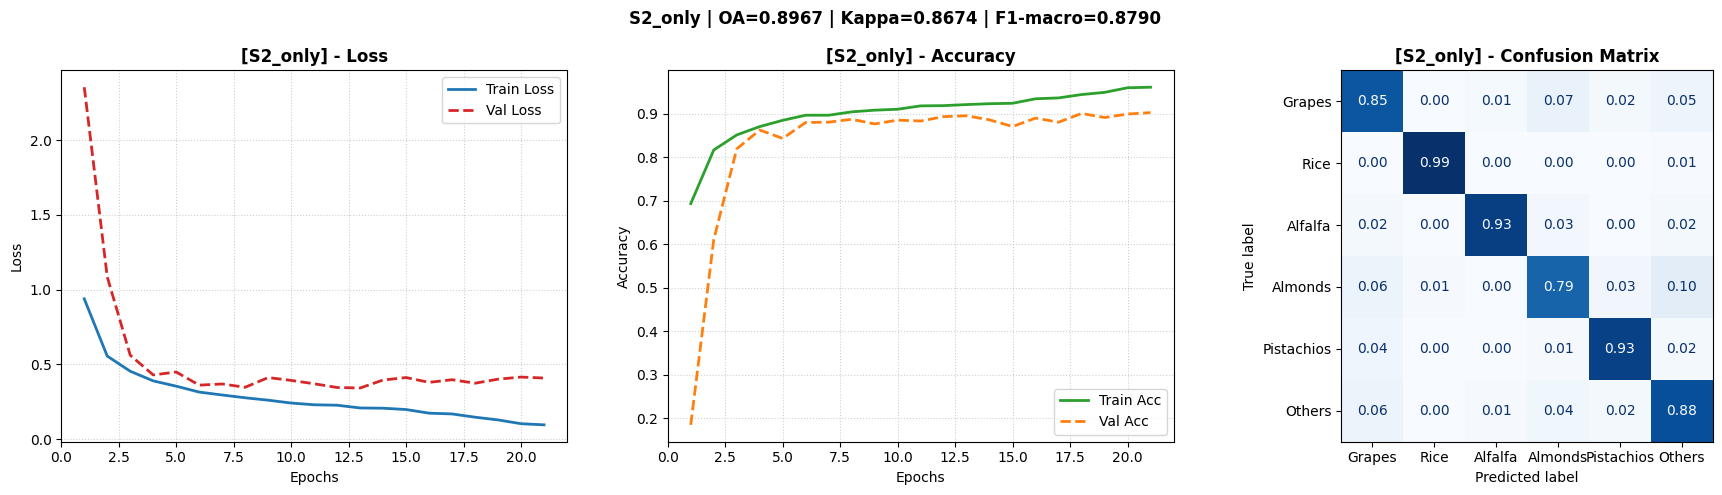

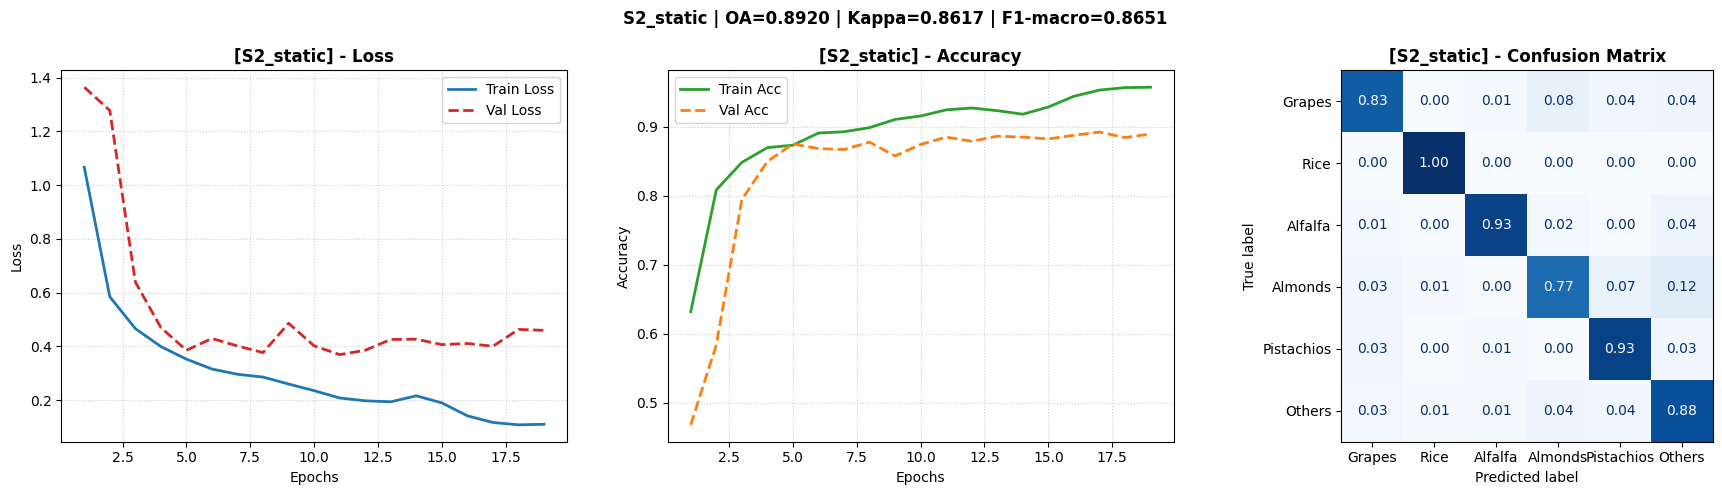

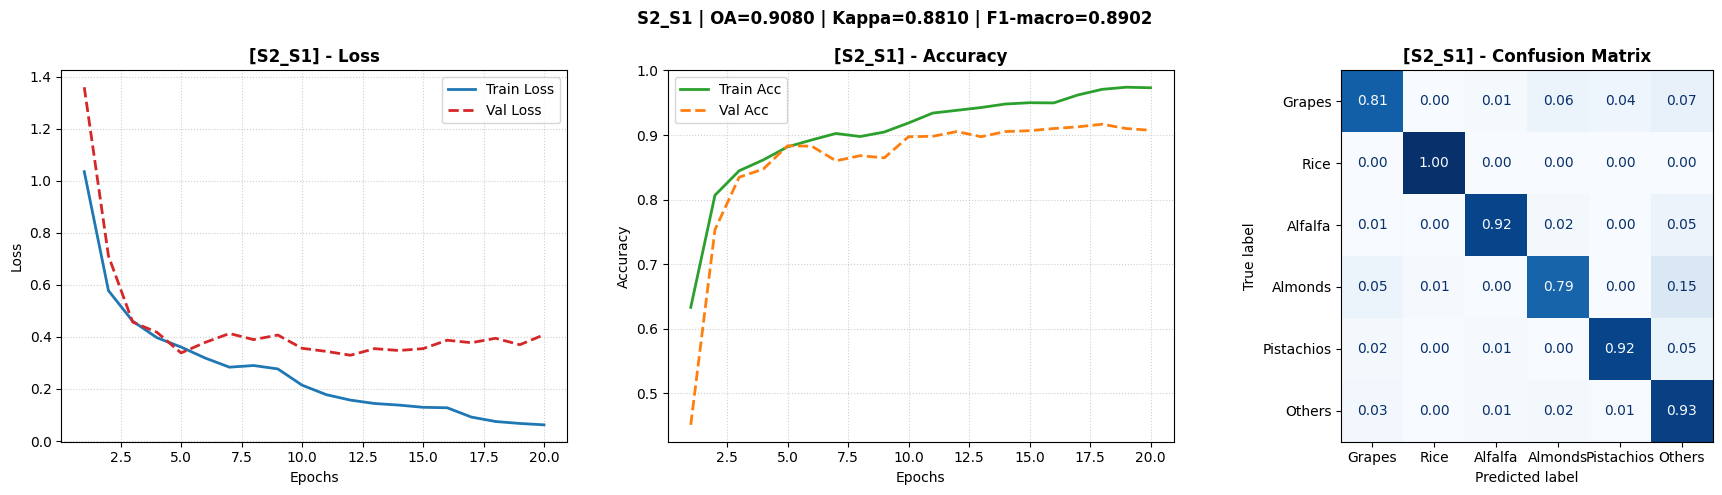

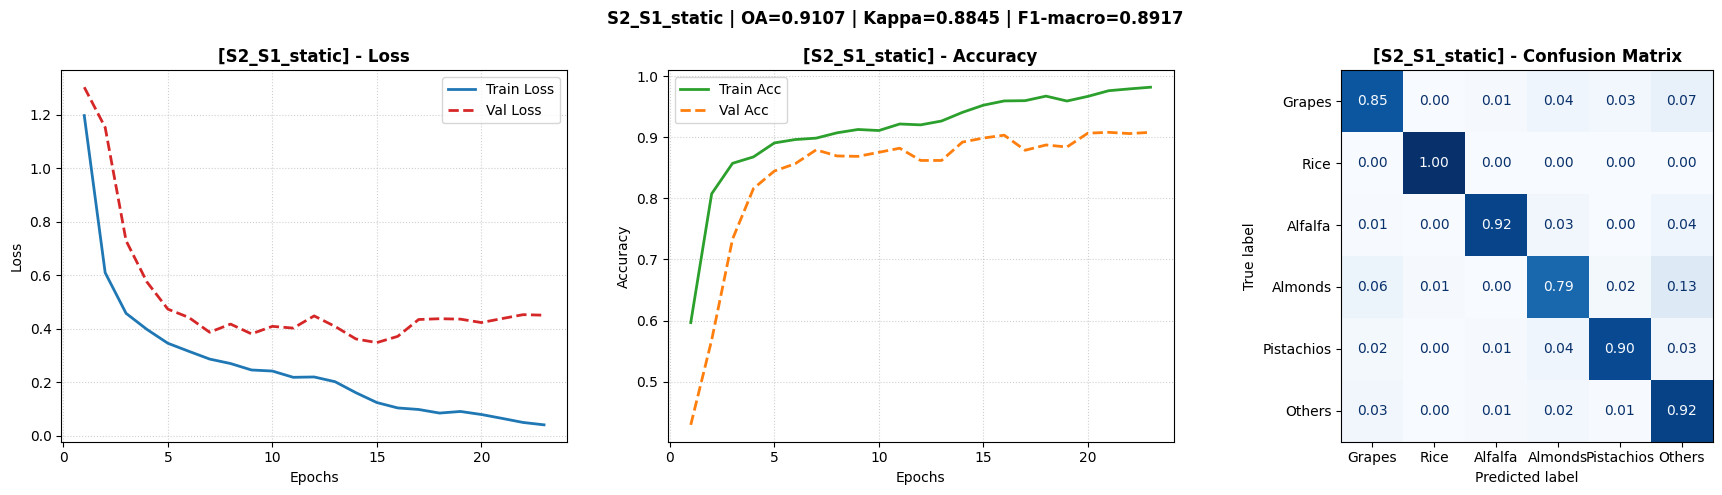

In [7]:
# 6) Visualisations: courbes d'entrainement + matrices de confusion
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, cohen_kappa_score, accuracy_score

configs = [
    ("S2_only", False, False),
    ("S2_static", False, True),
    ("S2_S1", True, False),
    ("S2_S1_static", True, True),
]

def make_inputs(idx, use_s1, use_static):
    s2 = X_s2_n[idx]
    if use_s1 and use_static:
        return [s2, X_s1_n[idx], X_static_n[idx]]
    if use_s1:
        return [s2, X_s1_n[idx]]
    if use_static:
        return [s2, X_static_n[idx]]
    return [s2]

y_true = y[idx_test]

for conf_name, use_s1, use_static in configs:
    info = ablation[conf_name]
    hist = info["history"].history

    # Courbes
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs_range = range(1, len(hist["loss"]) + 1)

    axes[0].plot(epochs_range, hist["loss"], label="Train Loss", color="#1f77b4", linewidth=2)
    axes[0].plot(epochs_range, hist["val_loss"], label="Val Loss", color="#d62728", linestyle="--", linewidth=2)
    axes[0].set_title(f"[{conf_name}] - Loss", fontweight="bold")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, linestyle=":", alpha=0.6)

    axes[1].plot(epochs_range, hist["accuracy"], label="Train Acc", color="#2ca02c", linewidth=2)
    axes[1].plot(epochs_range, hist["val_accuracy"], label="Val Acc", color="#ff7f0e", linestyle="--", linewidth=2)
    axes[1].set_title(f"[{conf_name}] - Accuracy", fontweight="bold")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, linestyle=":", alpha=0.6)

    # Prediction test + matrice
    X_test_in = make_inputs(idx_test, use_s1, use_static)
    y_pred = np.argmax(info["model"].predict(X_test_in, verbose=0), axis=-1)

    oa = accuracy_score(y_true, y_pred)
    kap = cohen_kappa_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(6), normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[2], cmap="Blues", colorbar=False, values_format=".2f")
    axes[2].set_title(f"[{conf_name}] - Confusion Matrix", fontweight="bold")

    plt.suptitle(
        f"{conf_name} | OA={oa:.4f} | Kappa={kap:.4f} | F1-macro={f1m:.4f}",
        fontsize=12,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

In [8]:
# 7) Export des figures (optionnel)
SAVE_FIGS = True
if SAVE_FIGS:
    fig_dir = PROJECT_ROOT / "runs" / "partie3_ablation" / "figures"
    fig_dir.mkdir(parents=True, exist_ok=True)

    for conf_name, use_s1, use_static in configs:
        info = ablation[conf_name]
        hist = info["history"].history
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        epochs_range = range(1, len(hist["loss"]) + 1)

        axes[0].plot(epochs_range, hist["loss"], label="Train Loss")
        axes[0].plot(epochs_range, hist["val_loss"], label="Val Loss", linestyle="--")
        axes[0].set_title("Loss")
        axes[0].legend()

        axes[1].plot(epochs_range, hist["accuracy"], label="Train Acc")
        axes[1].plot(epochs_range, hist["val_accuracy"], label="Val Acc", linestyle="--")
        axes[1].set_title("Accuracy")
        axes[1].legend()

        X_test_in = make_inputs(idx_test, use_s1, use_static)
        y_pred = np.argmax(info["model"].predict(X_test_in, verbose=0), axis=-1)
        cm = confusion_matrix(y[idx_test], y_pred, labels=np.arange(6), normalize="true")
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(ax=axes[2], cmap="Blues", colorbar=False, values_format=".2f")
        axes[2].set_title("Confusion Matrix")

        plt.tight_layout()
        out = fig_dir / f"{conf_name}_training_and_cm.png"
        plt.savefig(out, dpi=220, bbox_inches="tight")
        plt.close(fig)

    print(f"Figures saved to: {fig_dir}")

Figures saved to: C:\Users\pc\Desktop\projet_rcr\california\runs\partie3_ablation\figures
